# Stable and variable morphology visualized — fixed version

This version removes hidden kernel-state dependencies and makes the notebook reproducible from top to bottom.

What was fixed:
- avoids a hard-coded Windows-only path by allowing `DATA_DIR` to be set explicitly
- loads tables in a reusable way
- defines the missing `shorten_intensity_label()` helper
- rebuilds the missing `results` object from the loaded clustered tables
- writes output files relative to `DATA_DIR`


In [1]:

from pathlib import Path
import pandas as pd

# --- Choose where the CSV/XLSX files live ------------------------------------
# Option 1: set the folder explicitly on your machine
DATA_DIR = Path(r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML")



files = sorted([p for p in DATA_DIR.iterdir() if p.is_file()])
print(f"Using DATA_DIR: {DATA_DIR}")
for f in files:
    print(f.name)


Using DATA_DIR: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML
clearing metadata for ML.ipynb
combined_clustered_data_1462_k5.csv
combined_clustered_data_1476_k2.csv
selected_intensity_variability_results.csv


In [2]:

from pathlib import Path
import pandas as pd

tables = {}

for f in sorted(DATA_DIR.iterdir()):
    if not f.is_file():
        continue

    suffix = f.suffix.lower()

    try:
        if suffix == ".csv":
            tables[f.stem] = pd.read_csv(f)
            print(f"Loaded CSV:  {f.name} -> {tables[f.stem].shape}")

        elif suffix in [".xlsx", ".xls"]:
            tables[f.stem] = pd.read_excel(f)
            print(f"Loaded Excel: {f.name} -> {tables[f.stem].shape}")

    except Exception as e:
        print(f"Could not load {f.name}: {e}")

if not tables:
    raise RuntimeError(
        "No tables were loaded. Put the clustered CSV/XLSX files in DATA_DIR "
        "or point DATA_DIR to the correct folder."
    )


Loaded CSV:  combined_clustered_data_1462_k5.csv -> (410, 1971)
Loaded CSV:  combined_clustered_data_1476_k2.csv -> (667, 1971)


In [3]:
tables.keys()

dict_keys(['combined_clustered_data_1462_k5', 'combined_clustered_data_1476_k2'])

In [4]:

import re
import numpy as np
import pandas as pd


def shorten_intensity_label(metric_name):
    """Compact display label for long CellProfiler intensity feature names."""
    metric_name = str(metric_name)

    replacements = {
        "_IntegratedIntensityEdge_": " EdgeInt ",
        "_MeanIntensityEdge_": " EdgeMean ",
        "_StdIntensityEdge_": " EdgeStd ",
        "_MaxIntensityEdge_": " EdgeMax ",
        "_MinIntensityEdge_": " EdgeMin ",
        "_IntegratedIntensity_": " IntInt ",
        "_MeanIntensity_": " Mean ",
        "_StdIntensity_": " Std ",
        "_MaxIntensity_": " Max ",
        "_MinIntensity_": " Min ",
        "_LowerQuartileIntensity_": " Q1 ",
        "_MedianIntensity_": " Median ",
        "_MADIntensity_": " MAD ",
        "_UpperQuartileIntensity_": " Q3 ",
        "_Location_CenterMassIntensity_X_": " CMI_X ",
        "_Location_CenterMassIntensity_Y_": " CMI_Y ",
        "_Location_CenterMassIntensity_Z_": " CMI_Z ",
        "_Location_MaxIntensity_X_": " Max_X ",
        "_Location_MaxIntensity_Y_": " Max_Y ",
        "_Location_MaxIntensity_Z_": " Max_Z ",
        "_Intensity_": ": ",
    }

    s = metric_name
    for old, new in replacements.items():
        s = s.replace(old, new)

    s = (
        s.replace("phalloidin", "Phalloidin")
         .replace("yap", "YAP")
         .replace("dapi", "DAPI")
         .replace("_", " ")
    )
    s = re.sub(r"\s+", " ", s).strip()
    return s


def find_cluster_column(df):
    """Find the cluster-label column in a clustered table."""
    preferred = ["cluster", "Cluster", "cluster_id", "cluster_label", "labels", "label"]
    for c in preferred:
        if c in df.columns:
            return c

    candidates = [c for c in df.columns if "cluster" in c.lower() or c.lower() in {"label", "labels"}]
    if candidates:
        return candidates[0]

    raise KeyError(
        "Could not find a cluster column. Expected something like "
        "'cluster', 'Cluster', 'cluster_id', or 'label'."
    )


def get_intensity_columns(df, cluster_col):
    """Prefer CellProfiler intensity columns; otherwise fall back to numeric columns."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if cluster_col in numeric_cols:
        numeric_cols.remove(cluster_col)

    intensity_cols = [c for c in numeric_cols if "_Intensity_" in c]
    return intensity_cols if intensity_cols else numeric_cols


def rowwise_zscore(df):
    """Z-score each row independently."""
    row_means = df.mean(axis=1)
    row_stds = df.std(axis=1, ddof=0).replace(0, np.nan)
    return df.sub(row_means, axis=0).div(row_stds, axis=0).fillna(0.0)


def build_surface_summary(df, surface_name, selection_df=None, top_n=10, bottom_n=10):
    """
    Build the missing `results[surface]` entry expected by the plotting/export cells.

    Parameters
    ----------
    df : DataFrame
        Clustered single-cell table for one surface.
    surface_name : str
        Surface label, e.g. '1462'.
    selection_df : DataFrame or None
        Optional table with columns:
        surface, row_in_plot, metric_name, group
        If provided, it controls which rows are plotted and in what order.
    """
    cluster_col = find_cluster_column(df)
    intensity_cols = get_intensity_columns(df, cluster_col)

    if not intensity_cols:
        raise ValueError(f"No usable feature columns were found for surface {surface_name}.")

    cluster_means = df.groupby(cluster_col)[intensity_cols].mean().sort_index()
    variability_all = cluster_means.std(axis=0, ddof=0).sort_values(ascending=False)

    if selection_df is not None and not selection_df.empty:
        sel = selection_df[selection_df["surface"].astype(str) == str(surface_name)].copy()

        if "row_in_plot" in sel.columns:
            sel = sel.sort_values("row_in_plot")

        selected_feats = [f for f in sel["metric_name"].tolist() if f in cluster_means.columns]
        top_feats = [f for f in sel.loc[sel["group"] == "most_variable", "metric_name"].tolist() if f in selected_feats]
        bottom_feats = [f for f in sel.loc[sel["group"] != "most_variable", "metric_name"].tolist() if f in selected_feats]

        if not selected_feats:
            raise ValueError(
                f"No selected metrics for surface {surface_name} matched columns in the clustered table."
            )
    else:
        top_feats = variability_all.head(top_n).index.tolist()

        nonzero = variability_all[variability_all > 0].sort_values()
        bottom_feats = [f for f in nonzero.index.tolist() if f not in top_feats][:bottom_n]

        selected_feats = top_feats + bottom_feats

    heatmap_raw = cluster_means[selected_feats].T
    heatmap_scaled = rowwise_zscore(heatmap_raw)

    return {
        "surface_name": str(surface_name),
        "cluster_col": cluster_col,
        "cluster_means": cluster_means,
        "variability_all": variability_all,
        "selected_feats": selected_feats,
        "top_feats": top_feats,
        "bottom_feats": bottom_feats,
        "heatmap_scaled": heatmap_scaled,
    }


# Optional selection table from a previous export
selection_key = "selected_intensity_variability_results"
selection_df = tables.get(selection_key)

clustered_tables = {
    re.search(r"combined_clustered_data_(\d+)_k\d+", name).group(1): df
    for name, df in tables.items()
    if re.search(r"combined_clustered_data_(\d+)_k\d+", name)
}

if not clustered_tables:
    raise RuntimeError(
        "No clustered tables found. Expected filenames like "
        "'combined_clustered_data_1462_k5.csv'."
    )

results = {
    surface_name: build_surface_summary(df, surface_name, selection_df=selection_df)
    for surface_name, df in clustered_tables.items()
}

results.keys()


dict_keys(['1462', '1476'])

In [5]:

import numpy as np
import matplotlib.pyplot as plt


def plot_combined_surface_intensity_variability(
    surface_summaries,
    cmap_heatmap="coolwarm",
    cmap_std="Greys",
    vmin=-2.5,
    vmax=2.5,
    figsize=(22, 8),
    shorten_labels=False,
    show_heatmap_values=False,
    show_std_values=True,
    std_fmt="{:.3f}",
    label_fontsize=11,
    tick_fontsize=11,
    title_fontsize=20,
    cbar_fontsize=14,
    variability_scale="per_surface",  # "per_surface" or "global"
    cbar_label="Row-wise z-score of cluster mean intensity"
):
    """
    Plot two surfaces side by side, each with:
    - main heatmap: row-wise z-score of cluster means
    - side variability column: actual std across cluster means for each metric
    """

    if len(surface_summaries) != 2:
        raise ValueError("This plotting function expects exactly 2 surface summaries.")

    # Set global std range if requested
    if variability_scale == "global":
        all_std_vals = []
        for summary in surface_summaries:
            feats = summary["selected_feats"]
            vals = summary["variability_all"].loc[feats].to_numpy(dtype=float)
            all_std_vals.extend(vals)
        global_std_vmin = float(np.nanmin(all_std_vals))
        global_std_vmax = float(np.nanmax(all_std_vals))
    else:
        global_std_vmin = None
        global_std_vmax = None

    # Layout: heatmap1 | std1 | heatmap2 | std2 | colorbar
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        1, 5,
        width_ratios=[1.0, 0.22, 1.0, 0.22, 0.08]
    )

    ax_hm_1 = fig.add_subplot(gs[0, 0])
    ax_std_1 = fig.add_subplot(gs[0, 1], sharey=ax_hm_1)
    ax_hm_2 = fig.add_subplot(gs[0, 2])
    ax_std_2 = fig.add_subplot(gs[0, 3], sharey=ax_hm_2)
    cax = fig.add_subplot(gs[0, 4])

    heatmap_axes = [ax_hm_1, ax_hm_2]
    std_axes = [ax_std_1, ax_std_2]

    im_heat = None

    for idx, (ax_hm, ax_std, summary) in enumerate(zip(heatmap_axes, std_axes, surface_summaries)):
        heatmap_data = summary["heatmap_scaled"]
        row_labels = heatmap_data.index.tolist()
        col_labels = [f"C{c}" for c in heatmap_data.columns.tolist()]

        # Actual variability values for plotted rows
        std_vals = summary["variability_all"].loc[row_labels].to_numpy(dtype=float).reshape(-1, 1)

        if variability_scale == "global":
            std_vmin = global_std_vmin
            std_vmax = global_std_vmax
        else:
            std_vmin = float(np.nanmin(std_vals))
            std_vmax = float(np.nanmax(std_vals))

        if np.isclose(std_vmin, std_vmax):
            std_vmax = std_vmin + 1e-9

        # Main heatmap
        im_heat = ax_hm.imshow(
            heatmap_data.values,
            aspect="auto",
            cmap=cmap_heatmap,
            vmin=vmin,
            vmax=vmax
        )

        ax_hm.set_xticks(np.arange(len(col_labels)))
        ax_hm.set_xticklabels(col_labels, fontsize=tick_fontsize)
        ax_hm.set_xlabel("Cluster", fontsize=14)

        display_row_labels = []
        for feat in row_labels:
            feat_disp = shorten_intensity_label(feat) if shorten_labels else feat

            if feat in summary["top_feats"]:
                display_row_labels.append("↑ " + feat_disp)
            elif feat in summary["bottom_feats"]:
                display_row_labels.append("↓ " + feat_disp)
            else:
                display_row_labels.append(feat_disp)

        ax_hm.set_yticks(np.arange(len(display_row_labels)))
        ax_hm.set_yticklabels(display_row_labels, fontsize=label_fontsize)

        if idx == 0:
            ax_hm.yaxis.tick_left()
            ax_hm.tick_params(axis="y", labelleft=True, labelright=False, pad=4)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("right")
        else:
            ax_hm.yaxis.tick_right()
            ax_hm.tick_params(axis="y", labelleft=False, labelright=True, pad=4)
            for lab in ax_hm.get_yticklabels():
                lab.set_horizontalalignment("left")

        n_top = len(summary["top_feats"])
        ax_hm.axhline(n_top - 0.5, color="black", linewidth=1.2)

        ax_hm.set_title(
            f"Surface {summary['surface_name']}\n"
            f"{len(summary['top_feats'])} most variable + {len(summary['bottom_feats'])} least variable\n"
            f"(variability across cluster means)",
            fontsize=title_fontsize
        )

        if show_heatmap_values:
            for i in range(heatmap_data.shape[0]):
                for j in range(heatmap_data.shape[1]):
                    ax_hm.text(
                        j, i,
                        f"{heatmap_data.values[i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=7
                    )

        # Std side column
        ax_std.imshow(
            std_vals,
            aspect="auto",
            cmap=cmap_std,
            vmin=std_vmin,
            vmax=std_vmax
        )

        ax_std.set_xticks([0])
        ax_std.set_xticklabels(["std"], fontsize=tick_fontsize, rotation=90)
        ax_std.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        ax_std.axhline(n_top - 0.5, color="black", linewidth=1.2)

        if show_std_values:
            std_norm = (std_vals.flatten() - std_vmin) / (std_vmax - std_vmin + 1e-12)
            for i, (val, norm_val) in enumerate(zip(std_vals.flatten(), std_norm)):
                text_color = "white" if norm_val > 0.6 else "black"
                ax_std.text(
                    0, i,
                    std_fmt.format(val),
                    ha="center", va="center",
                    fontsize=9,
                    color=text_color
                )

    cbar = fig.colorbar(im_heat, cax=cax)
    cbar.set_label(cbar_label, fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    fig.subplots_adjust(left=0.23, right=0.88, wspace=0.35)
    plt.show()

    return fig, {
        "heatmap_axes": heatmap_axes,
        "std_axes": std_axes,
        "colorbar_axis": cax
    }


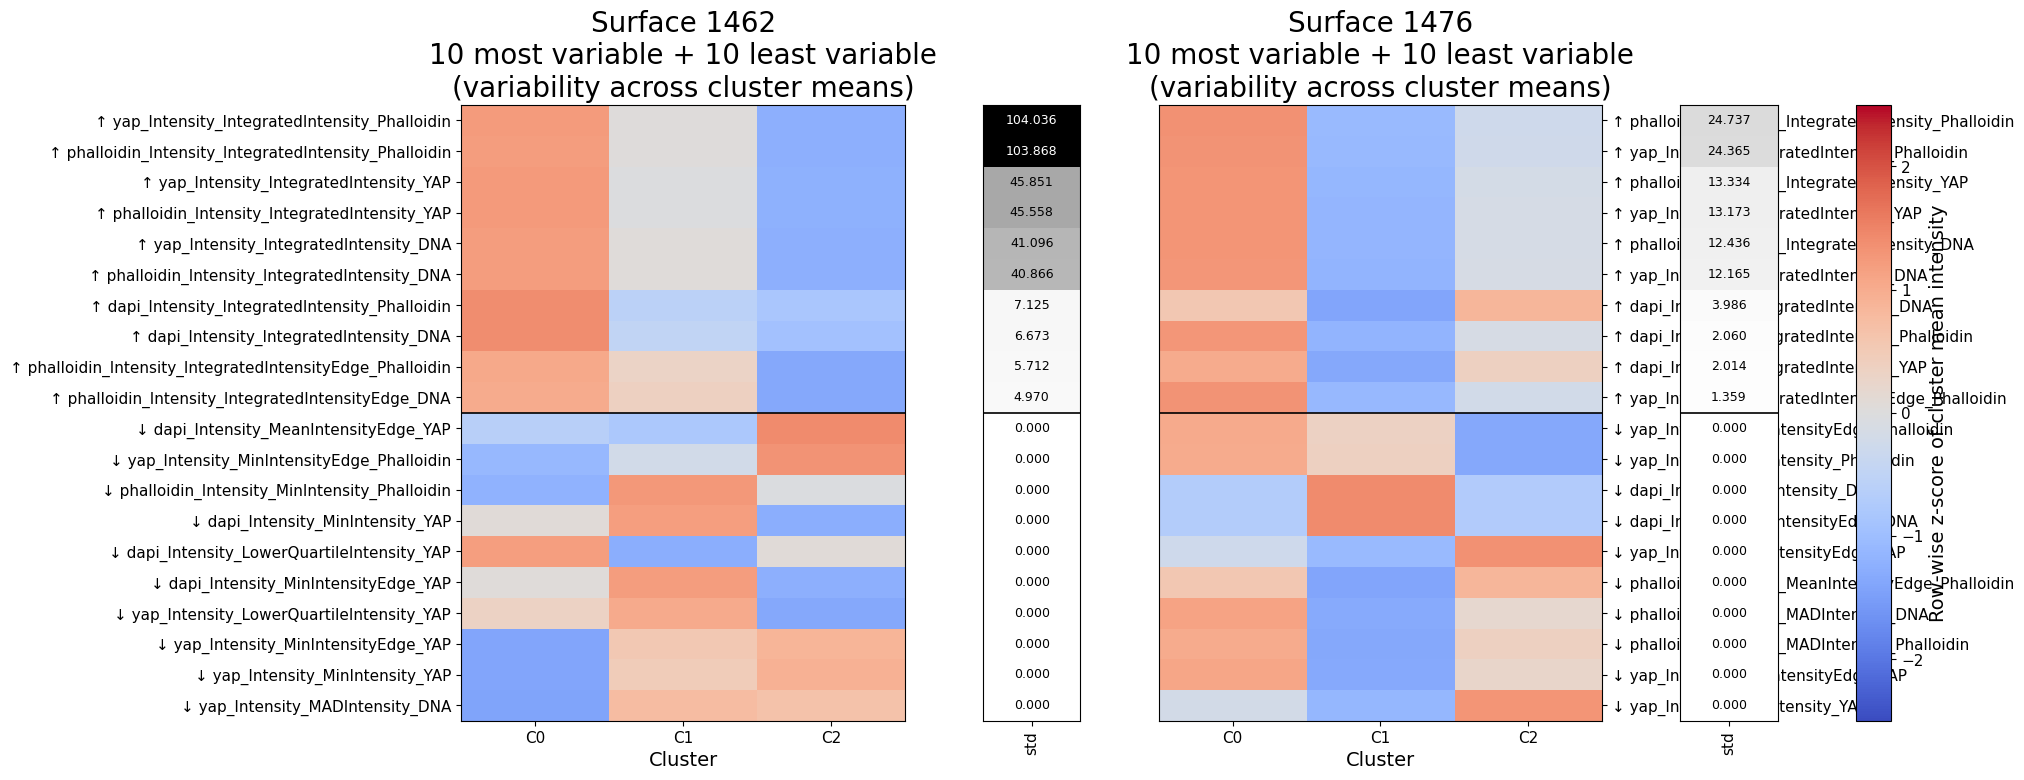

In [6]:

# Expecting exactly two surfaces, e.g. 1462 and 1476
surface_order = sorted(results.keys())
if len(surface_order) != 2:
    raise ValueError(f"Expected exactly 2 surfaces, found: {surface_order}")

fig, axes_dict = plot_combined_surface_intensity_variability(
    [results[surface_order[0]], results[surface_order[1]]],
    shorten_labels=False,
    show_std_values=True,
    variability_scale="global"
)


In [ ]:

export_table = pd.concat([
    pd.DataFrame({
        "surface": surface_name,
        "row_in_plot": range(1, len(summary["selected_feats"]) + 1),
        "metric_name": summary["selected_feats"],
        "group": [
            "most_variable" if f in summary["top_feats"] else "least_variable_nonzero"
            for f in summary["selected_feats"]
        ],
        "variability_std": [summary["variability_all"][f] for f in summary["selected_feats"]]
    })
    for surface_name, summary in results.items()
], ignore_index=True)

export_path = DATA_DIR / "selected_intensity_variability_results.csv"
export_table.to_csv(export_path, index=False)

print(f"Saved: {export_path}")
export_table.head()


In [ ]:

import re
from IPython.display import display


def explain_cp_metric(metric_name):
    """
    Convert a CellProfiler-style metric name into a short human-readable explanation.
    Expected style:
        <object>_Intensity_<measurement>_<channel>
    Example:
        dapi_Intensity_IntegratedIntensity_DNA
    """

    metric_name = str(metric_name)

    object_map = {
        "dapi": "segmented DAPI object",
        "phalloidin": "segmented phalloidin object",
        "yap": "segmented YAP object",
    }

    channel_map = {
        "DNA": "DNA channel",
        "Phalloidin": "phalloidin channel",
        "YAP": "YAP channel",
    }

    measurement_map = {
        "IntegratedIntensity": "sum of pixel intensities",
        "MeanIntensity": "mean pixel intensity",
        "StdIntensity": "standard deviation of pixel intensities",
        "MaxIntensity": "maximum pixel intensity",
        "MinIntensity": "minimum pixel intensity",
        "IntegratedIntensityEdge": "sum of edge-pixel intensities",
        "MeanIntensityEdge": "mean edge-pixel intensity",
        "StdIntensityEdge": "standard deviation of edge-pixel intensities",
        "MaxIntensityEdge": "maximum edge-pixel intensity",
        "MinIntensityEdge": "minimum edge-pixel intensity",
        "MassDisplacement": "distance between the binary-shape center and the intensity-weighted center",
        "LowerQuartileIntensity": "25th percentile of pixel intensities",
        "MedianIntensity": "median pixel intensity",
        "MADIntensity": "median absolute deviation of pixel intensities",
        "UpperQuartileIntensity": "75th percentile of pixel intensities",
        "Location_CenterMassIntensity_X": "X coordinate of the intensity-weighted center",
        "Location_CenterMassIntensity_Y": "Y coordinate of the intensity-weighted center",
        "Location_CenterMassIntensity_Z": "Z coordinate of the intensity-weighted center",
        "Location_MaxIntensity_X": "X coordinate of the brightest pixel",
        "Location_MaxIntensity_Y": "Y coordinate of the brightest pixel",
        "Location_MaxIntensity_Z": "Z coordinate of the brightest pixel",
    }

    percentile_match = re.search(r"(^|_)Percentile_(\d+)(_|$)", metric_name)
    percentile_text = None
    if percentile_match:
        p = percentile_match.group(2)
        percentile_text = f"{p}th percentile of pixel intensities"

    parts = metric_name.split("_")
    obj_prefix = parts[0] if len(parts) > 0 else None
    obj_text = object_map.get(obj_prefix, f"object '{obj_prefix}'" if obj_prefix else "object")

    channel_text = None
    for token in reversed(parts):
        if token in channel_map:
            channel_text = channel_map[token]
            break

    measurement_text = None
    for key, value in measurement_map.items():
        if key in metric_name:
            measurement_text = value
            break

    if measurement_text is None and percentile_text is not None:
        measurement_text = percentile_text

    if measurement_text is None:
        measurement_text = "intensity-derived measurement"

    if channel_text is not None:
        return f"{measurement_text} in the {channel_text}, measured within the {obj_text}"
    return f"{measurement_text} measured within the {obj_text}"


export_table = pd.read_csv(export_path)
export_table["metric_explanation"] = export_table["metric_name"].apply(explain_cp_metric)

explained_path = DATA_DIR / "selected_intensity_variability_results_explained.csv"
export_table.to_csv(explained_path, index=False)

print(f"Saved: {explained_path}")
display(export_table.head(20))
